# Разделение речи и пауз


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import subprocess
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

from IPython.display import display

from scipy.signal import butter, lfilter, resample_poly
from scipy.ndimage import binary_closing, binary_opening

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.facecolor'] = '#f8fafc'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['grid.color'] = '#cbd5e1'
plt.rcParams['font.size'] = 11


RNG = np.random.default_rng(42)
SNR_LEVELS = [20, 10, 1, -3, -6]
NOISE_TYPES = ['gaussian', 'road', 'music']
TARGET_SR = 16000
PAD_SEC = 0.5
FRAME_SEC = 0.025
HOP_SEC = 0.010

REF_DELTA_DB = 40.0
CLASSIC_NOISE_STD_K = 0.5


In [2]:
file_names = ['Банан.wav', 'Капуста.wav', 'Папа.wav']
problem_dir = Path('/home/nikita/Code/MSU/Rech_Max/Problem1')

if not problem_dir.exists():
    raise FileNotFoundError(f'Папка не найдена: {problem_dir}')

audio_files = [problem_dir / name for name in file_names]

audio_overview_rows = []
for p in audio_files:
    x, sr = sf.read(p)
    dur = len(x) / sr
    audio_overview_rows.append({'file': p.name, 'sr': sr, 'duration_sec': dur})

audio_overview = pd.DataFrame(audio_overview_rows).round(3)
audio_overview


,file,sr,duration_sec
0,Банан.wav,48000,0.552
1,Капуста.wav,48000,0.576
2,Папа.wav,48000,0.384


In [3]:
def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x.astype(np.float32)
    return x.mean(axis=1).astype(np.float32)


def normalize_peak(x: np.ndarray, peak: float = 0.98) -> np.ndarray:
    x = x.astype(np.float32)
    m = np.max(np.abs(x)) + 1e-12
    return peak * x / m


def maybe_resample(x: np.ndarray, sr: int, target_sr: int) -> tuple[np.ndarray, int]:
    if sr == target_sr:
        return x.astype(np.float32), sr
    g = np.gcd(sr, target_sr)
    up = target_sr // g
    down = sr // g
    y = resample_poly(x, up=up, down=down).astype(np.float32)
    return y, target_sr


def add_silence_pad(x: np.ndarray, sr: int, pad_sec: float = 0.5) -> np.ndarray:
    pad_n = int(round(pad_sec * sr))
    return np.pad(x, (pad_n, pad_n), mode='constant')


def frame_signal(x: np.ndarray, frame_len: int, hop_len: int) -> np.ndarray:
    if len(x) < frame_len:
        x = np.pad(x, (0, frame_len - len(x)))
    rem = (len(x) - frame_len) % hop_len
    if rem != 0:
        x = np.pad(x, (0, hop_len - rem))
    n_frames = 1 + (len(x) - frame_len) // hop_len
    idx = hop_len * np.arange(n_frames)[:, None] + np.arange(frame_len)[None, :]
    return x[idx]


def extract_frame_features(x: np.ndarray, sr: int, frame_len: int, hop_len: int) -> tuple[np.ndarray, np.ndarray]:
    eps = 1e-10
    frames = frame_signal(x, frame_len, hop_len)
    win = np.hamming(frame_len).astype(np.float32)
    wf = frames * win[None, :]

    energy = np.mean(wf**2, axis=1) + eps
    log_energy = 10.0 * np.log10(energy)

    signs = np.sign(frames)
    zcr = np.mean(np.abs(np.diff(signs, axis=1)), axis=1) / 2.0

    spec = np.abs(np.fft.rfft(wf, axis=1)) + eps
    freqs = np.fft.rfftfreq(frame_len, d=1/sr)

    spec_sum = np.sum(spec, axis=1) + eps
    centroid = np.sum(spec * freqs[None, :], axis=1) / spec_sum
    bw = np.sqrt(np.sum(spec * (freqs[None, :] - centroid[:, None])**2, axis=1) / spec_sum)

    csum = np.cumsum(spec, axis=1)
    roll_idx = np.argmax(csum >= 0.85 * csum[:, [-1]], axis=1)
    rolloff = freqs[roll_idx]

    flatness = np.exp(np.mean(np.log(spec), axis=1)) / (np.mean(spec, axis=1) + eps)

    feat = np.column_stack([log_energy, zcr, centroid, bw, rolloff, flatness]).astype(np.float32)
    frame_t = (np.arange(len(feat)) * hop_len + frame_len / 2) / sr
    return feat, frame_t


def smooth_mask(mask: np.ndarray, close_k: int = 4, open_k: int = 3, min_len: int = 3) -> np.ndarray:
    if len(mask) == 0:
        return mask
    m = mask.astype(bool)
    if close_k > 1:
        m = binary_closing(m, structure=np.ones(close_k, dtype=bool))
    if open_k > 1:
        m = binary_opening(m, structure=np.ones(open_k, dtype=bool))

    out = m.copy()
    i = 0
    while i < len(out):
        if out[i]:
            j = i
            while j < len(out) and out[j]:
                j += 1
            if (j - i) < min_len:
                out[i:j] = False
            i = j
        else:
            i += 1
    return out


def mask_to_main_interval(mask: np.ndarray, hop_len: int, frame_len: int, sr: int) -> tuple[float, float]:
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return np.nan, np.nan

    chunks = []
    s = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            chunks.append((s, prev))
            s = i
            prev = i
    chunks.append((s, prev))

    best = max(chunks, key=lambda p: p[1] - p[0])
    start_frame, end_frame = best
    start_s = (start_frame * hop_len) / sr
    end_s = (end_frame * hop_len + frame_len) / sr
    return float(start_s), float(end_s)


def interval_to_frame_labels(frame_t: np.ndarray, interval: tuple[float, float]) -> np.ndarray:
    s, e = interval
    return ((frame_t >= s) & (frame_t <= e)).astype(np.int32)


In [4]:
def detect_reference_interval_clean(x: np.ndarray, sr: int) -> tuple[float, float]:
    frame_len = int(round(FRAME_SEC * sr))
    hop_len = int(round(HOP_SEC * sr))
    feat, _ = extract_frame_features(x, sr, frame_len, hop_len)
    log_energy = feat[:, 0]

    thr = np.max(log_energy) - REF_DELTA_DB
    mask = log_energy > thr
    mask = smooth_mask(mask, close_k=5, open_k=3, min_len=3)

    s, e = mask_to_main_interval(mask, hop_len, frame_len, sr)
    return s, e


def classical_vad_interval(x: np.ndarray, sr: int, pad_sec: float = 0.5) -> tuple[tuple[float, float], np.ndarray, np.ndarray]:
    frame_len = int(round(FRAME_SEC * sr))
    hop_len = int(round(HOP_SEC * sr))
    feat, frame_t = extract_frame_features(x, sr, frame_len, hop_len)
    log_energy = feat[:, 0]

    n_pad_frames = max(2, int(round(pad_sec / HOP_SEC)))
    noise_stat = np.concatenate([log_energy[:n_pad_frames], log_energy[-n_pad_frames:]])

    # Порог относительно статистики шума (двигается CLASSIC_NOISE_STD_K)
    thr = noise_stat.mean() + CLASSIC_NOISE_STD_K * (noise_stat.std() + 1e-6)
    mask = log_energy > thr

    mask = smooth_mask(mask, close_k=4, open_k=3, min_len=3)
    interval = mask_to_main_interval(mask, hop_len, frame_len, sr)
    return interval, mask, frame_t


In [5]:
def generate_noise(noise_type: str, n: int, sr: int, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(n) / sr

    if noise_type == 'gaussian':
        noise = rng.normal(0, 1, size=n)

    elif noise_type == 'road':
        # Низкочастотный "гул дороги" + среднечастотный шорох + редкие "гудки"
        white1 = rng.normal(0, 1, size=n)
        white2 = rng.normal(0, 1, size=n)

        b_lp, a_lp = butter(4, 220 / (sr / 2), btype='low')
        rumble = lfilter(b_lp, a_lp, white1)

        b_bp, a_bp = butter(3, [300 / (sr / 2), 3000 / (sr / 2)], btype='band')
        hiss = lfilter(b_bp, a_bp, white2)

        honk = np.zeros(n, dtype=np.float32)
        n_honks = max(1, int((n / sr) * 1.2))
        for _ in range(n_honks):
            dur = rng.uniform(0.06, 0.18)
            f0 = rng.uniform(280, 520)
            amp = rng.uniform(0.2, 0.6)
            start = rng.integers(0, max(1, n - int(dur * sr) - 1))
            m = int(dur * sr)
            env = np.hanning(max(4, m))
            tone = np.sin(2 * np.pi * f0 * np.arange(m) / sr)
            honk[start:start+m] += amp * env[:m] * tone[:m]

        noise = 0.75 * rumble + 0.35 * hiss + 0.25 * honk

    elif noise_type == 'music':
        # Синтетический музыкальный фон: аккорды + ритмические пульсации
        noise = np.zeros(n, dtype=np.float32)

        chord_pool = [
            [261.63, 329.63, 392.00],   # C major
            [220.00, 261.63, 329.63],   # A minor
            [196.00, 246.94, 392.00],   # G major
            [174.61, 220.00, 293.66],   # F major
        ]
        seg = int(0.35 * sr)
        for k in range(0, n, seg):
            chord = chord_pool[(k // seg) % len(chord_pool)]
            m = min(seg, n - k)
            tt = np.arange(m) / sr
            part = np.zeros(m, dtype=np.float32)
            for f in chord:
                part += 0.28 * np.sin(2 * np.pi * f * tt)
                part += 0.10 * np.sin(2 * np.pi * 2 * f * tt)
            env = 0.55 + 0.45 * np.sin(2 * np.pi * 1.8 * tt + 0.6)
            noise[k:k+m] += part * env.astype(np.float32)

        # Биты
        beat_hz = 2.2
        beat = (np.sin(2 * np.pi * beat_hz * t) > 0.98).astype(np.float32)
        beat = lfilter([1.0], [1.0, -0.92], beat)
        low_tone = np.sin(2 * np.pi * 90 * t)
        noise += 0.28 * beat * low_tone

        # Легкий "тарелочный" шум
        hats = rng.normal(0, 1, size=n)
        b_hp, a_hp = butter(3, 3500 / (sr / 2), btype='high')
        hats = lfilter(b_hp, a_hp, hats)
        noise += 0.06 * hats

    else:
        raise ValueError(f'Неизвестный тип шума: {noise_type}')

    noise = noise.astype(np.float32)
    noise = noise - np.mean(noise)
    noise /= (np.std(noise) + 1e-10)
    return noise


def mix_with_target_snr(clean: np.ndarray, noise: np.ndarray, snr_db: float, speech_slice: slice) -> np.ndarray:
    p_signal = np.var(clean[speech_slice]) + 1e-12
    p_noise = np.var(noise[speech_slice]) + 1e-12

    snr_lin = 10 ** (snr_db / 10.0)
    target_noise_power = p_signal / snr_lin
    scale = np.sqrt(target_noise_power / p_noise)

    mixed = clean + scale * noise
    return mixed.astype(np.float32)


In [6]:
# Загрузка слов, нормализация, ресемплинг, добавление 0.5 сек тишины
records = {}
for p in audio_files:
    x, sr = sf.read(p)
    x = to_mono(x)
    x = normalize_peak(x, peak=0.98)
    x, sr = maybe_resample(x, sr, TARGET_SR)
    x_pad = add_silence_pad(x, sr, pad_sec=PAD_SEC)

    pad_n = int(round(PAD_SEC * sr))
    speech_slice = slice(pad_n, pad_n + len(x))
    ref_interval = detect_reference_interval_clean(x_pad, sr)

    records[p.stem] = {
        'sr': sr,
        'clean_raw': x,
        'clean_pad': x_pad,
        'speech_slice': speech_slice,
        'ref_interval': ref_interval,
    }

records_overview = pd.DataFrame([
    {
        'word': word,
        'duration_with_pad_sec': len(d['clean_pad']) / d['sr'],
        'sr': d['sr'],
        'ref_start_sec': d['ref_interval'][0],
        'ref_end_sec': d['ref_interval'][1],
    }
    for word, d in records.items()
]).round(3)
records_overview


,word,duration_with_pad_sec,sr,ref_start_sec,ref_end_sec
0,Банан,1.552,16000,0.52,1.065
1,Капуста,1.576,16000,0.52,1.095
2,Папа,1.384,16000,0.53,0.895


# Визуализация чистых сигналов и эталонных границ



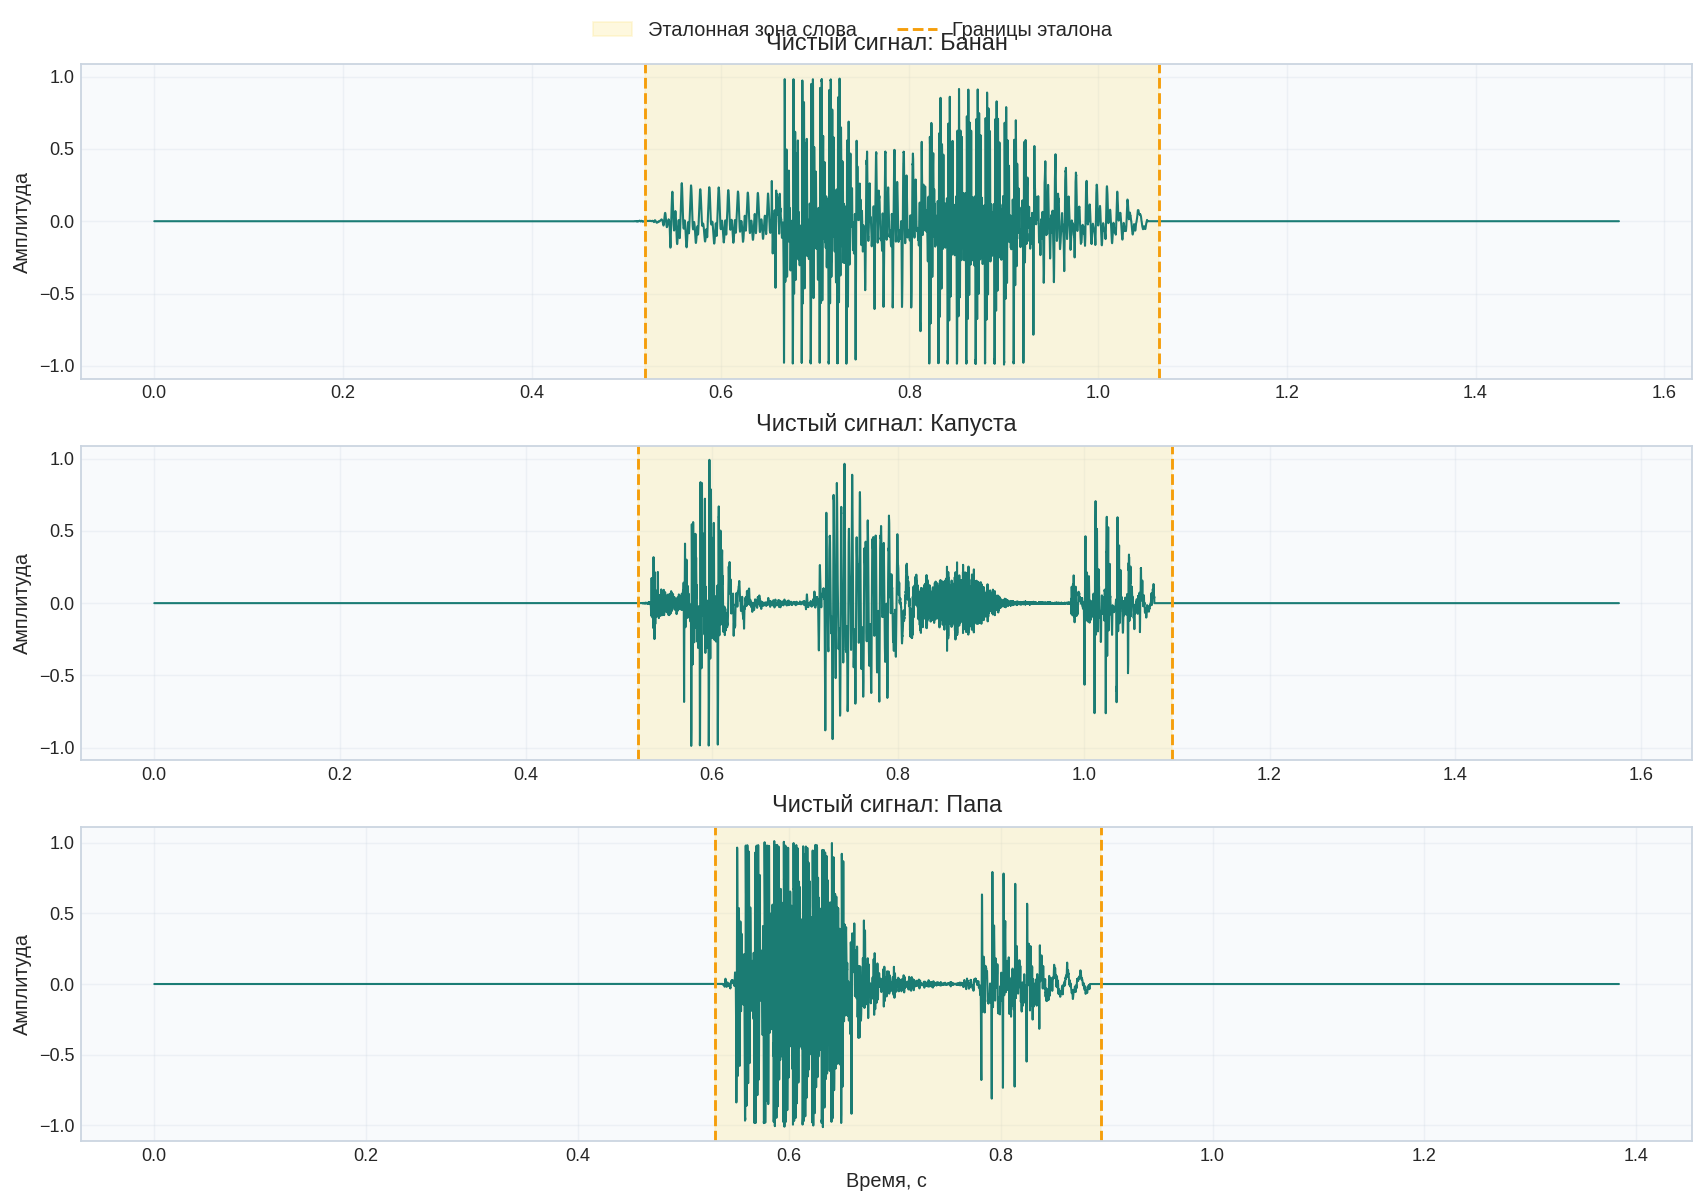

In [7]:
# Визуализация чистых сигналов и эталонных границ
fig, axes = plt.subplots(len(records), 1, figsize=(13, 3.0 * len(records)), sharex=False, constrained_layout=True)
if len(records) == 1:
    axes = [axes]

for ax, (word, d) in zip(axes, records.items()):
    x = d['clean_pad']
    sr = d['sr']
    t = np.arange(len(x)) / sr
    s_ref, e_ref = d['ref_interval']

    ax.plot(t, x, color='#0f766e', lw=1.15, alpha=0.95)
    ax.axvspan(s_ref, e_ref, color='#fde68a', alpha=0.28, label='Эталонная зона слова')
    ax.axvline(s_ref, color='#f59e0b', ls='--', lw=1.6, label='Границы эталона')
    ax.axvline(e_ref, color='#f59e0b', ls='--', lw=1.6)

    ax.set_title(f'Чистый сигнал: {word}', fontsize=13, pad=8)
    ax.set_ylabel('Амплитуда', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

axes[-1].set_xlabel('Время, с', fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=11)
plt.show()


In [8]:
# Предобученный нейросетевой VAD (Silero ONNX), без обучения
import onnxruntime as ort


def ensure_silero_onnx_model(cache_dir: Path) -> Path:
    cache_dir.mkdir(parents=True, exist_ok=True)
    model_path = cache_dir / 'silero_vad.onnx'

    if not model_path.exists():
        wheels = sorted(cache_dir.glob('silero_vad-*.whl'))
        if not wheels:
            subprocess.run(
                [sys.executable, '-m', 'pip', 'download', '--no-deps', '--dest', str(cache_dir), 'silero-vad==6.2.1'],
                check=True,
            )
            wheels = sorted(cache_dir.glob('silero_vad-*.whl'))
        wheel = wheels[-1]

        with zipfile.ZipFile(wheel) as zf:
            model_bytes = zf.read('silero_vad/data/silero_vad.onnx')
        model_path.write_bytes(model_bytes)

    return model_path


class SileroOnnxVad:
    def __init__(self, model_path: Path, ort_module):
        self.ort = ort_module
        opts = self.ort.SessionOptions()
        opts.inter_op_num_threads = 1
        opts.intra_op_num_threads = 1
        self.session = self.ort.InferenceSession(str(model_path), providers=['CPUExecutionProvider'], sess_options=opts)
        self.reset_states(batch_size=1)

    def reset_states(self, batch_size: int = 1):
        self.state = np.zeros((2, batch_size, 128), dtype=np.float32)
        self.context = np.zeros((batch_size, 64), dtype=np.float32)
        self.last_sr = 0
        self.last_batch = 0

    def _validate_and_resample(self, x: np.ndarray, sr: int) -> tuple[np.ndarray, int]:
        x = np.asarray(x, dtype=np.float32)
        if x.ndim == 1:
            x = x[None, :]
        if x.ndim != 2:
            raise ValueError(f'Ожидался 1D/2D сигнал, получено ndim={x.ndim}')

        if sr != 16000 and sr % 16000 == 0:
            step = sr // 16000
            x = x[:, ::step]
            sr = 16000

        if sr not in (8000, 16000):
            raise ValueError('Silero ONNX поддерживает 8k или 16k (или кратные 16k)')

        return x, sr

    def predict_prob(self, x: np.ndarray, sr: int) -> tuple[np.ndarray, int, int]:
        x, sr = self._validate_and_resample(x, sr)

        chunk = 512 if sr == 16000 else 256
        context = 64 if sr == 16000 else 32

        pad = (chunk - (x.shape[1] % chunk)) % chunk
        if pad:
            x = np.pad(x, ((0, 0), (0, pad)), mode='constant')

        batch = x.shape[0]
        self.reset_states(batch_size=batch)
        probs = []

        for i in range(0, x.shape[1], chunk):
            frame = x[:, i:i + chunk]
            x_in = np.concatenate([self.context, frame], axis=1).astype(np.float32)

            out, new_state = self.session.run(
                None,
                {
                    'input': x_in,
                    'state': self.state,
                    'sr': np.array(sr, dtype=np.int64),
                },
            )

            self.state = new_state.astype(np.float32)
            self.context = x_in[:, -context:]
            probs.append(out[:, 0].astype(np.float32))

        probs = np.stack(probs, axis=1)
        return probs[0], sr, chunk


silero_model_path = ensure_silero_onnx_model(Path('/tmp/rech_vad_cache'))
silero_vad_model = SileroOnnxVad(silero_model_path, ort)

silero_model_path


PosixPath('/tmp/rech_vad_cache/silero_vad.onnx')

In [9]:
# Подбор порога Silero VAD без обучения (калибровка только порога)

def silero_probs_for_signal(x: np.ndarray, sr: int):
    probs, sr_vad, chunk = silero_vad_model.predict_prob(x, sr)
    t = (np.arange(len(probs)) * chunk + chunk / 2) / sr_vad
    return probs, t, sr_vad, chunk


def interval_from_silero_probs(probs: np.ndarray, chunk: int, sr: int, thr: float):
    mask = probs >= thr
    mask = smooth_mask(mask, close_k=2, open_k=1, min_len=1)
    return mask_to_main_interval(mask, hop_len=chunk, frame_len=chunk, sr=sr), mask


thr_grid = np.linspace(0.20, 0.80, 61)
err_grid = []

for th in thr_grid:
    errs = []
    for word, d in records.items():
        probs, t, sr_vad, chunk = silero_probs_for_signal(d['clean_pad'], d['sr'])
        (s, e), _ = interval_from_silero_probs(probs, chunk, sr_vad, th)
        rs, re = d['ref_interval']
        errs.append((abs(s - rs) + abs(e - re)) / 2)
    err_grid.append(float(np.mean(errs)))

best_idx = int(np.argmin(err_grid))
silero_thr = float(thr_grid[best_idx])


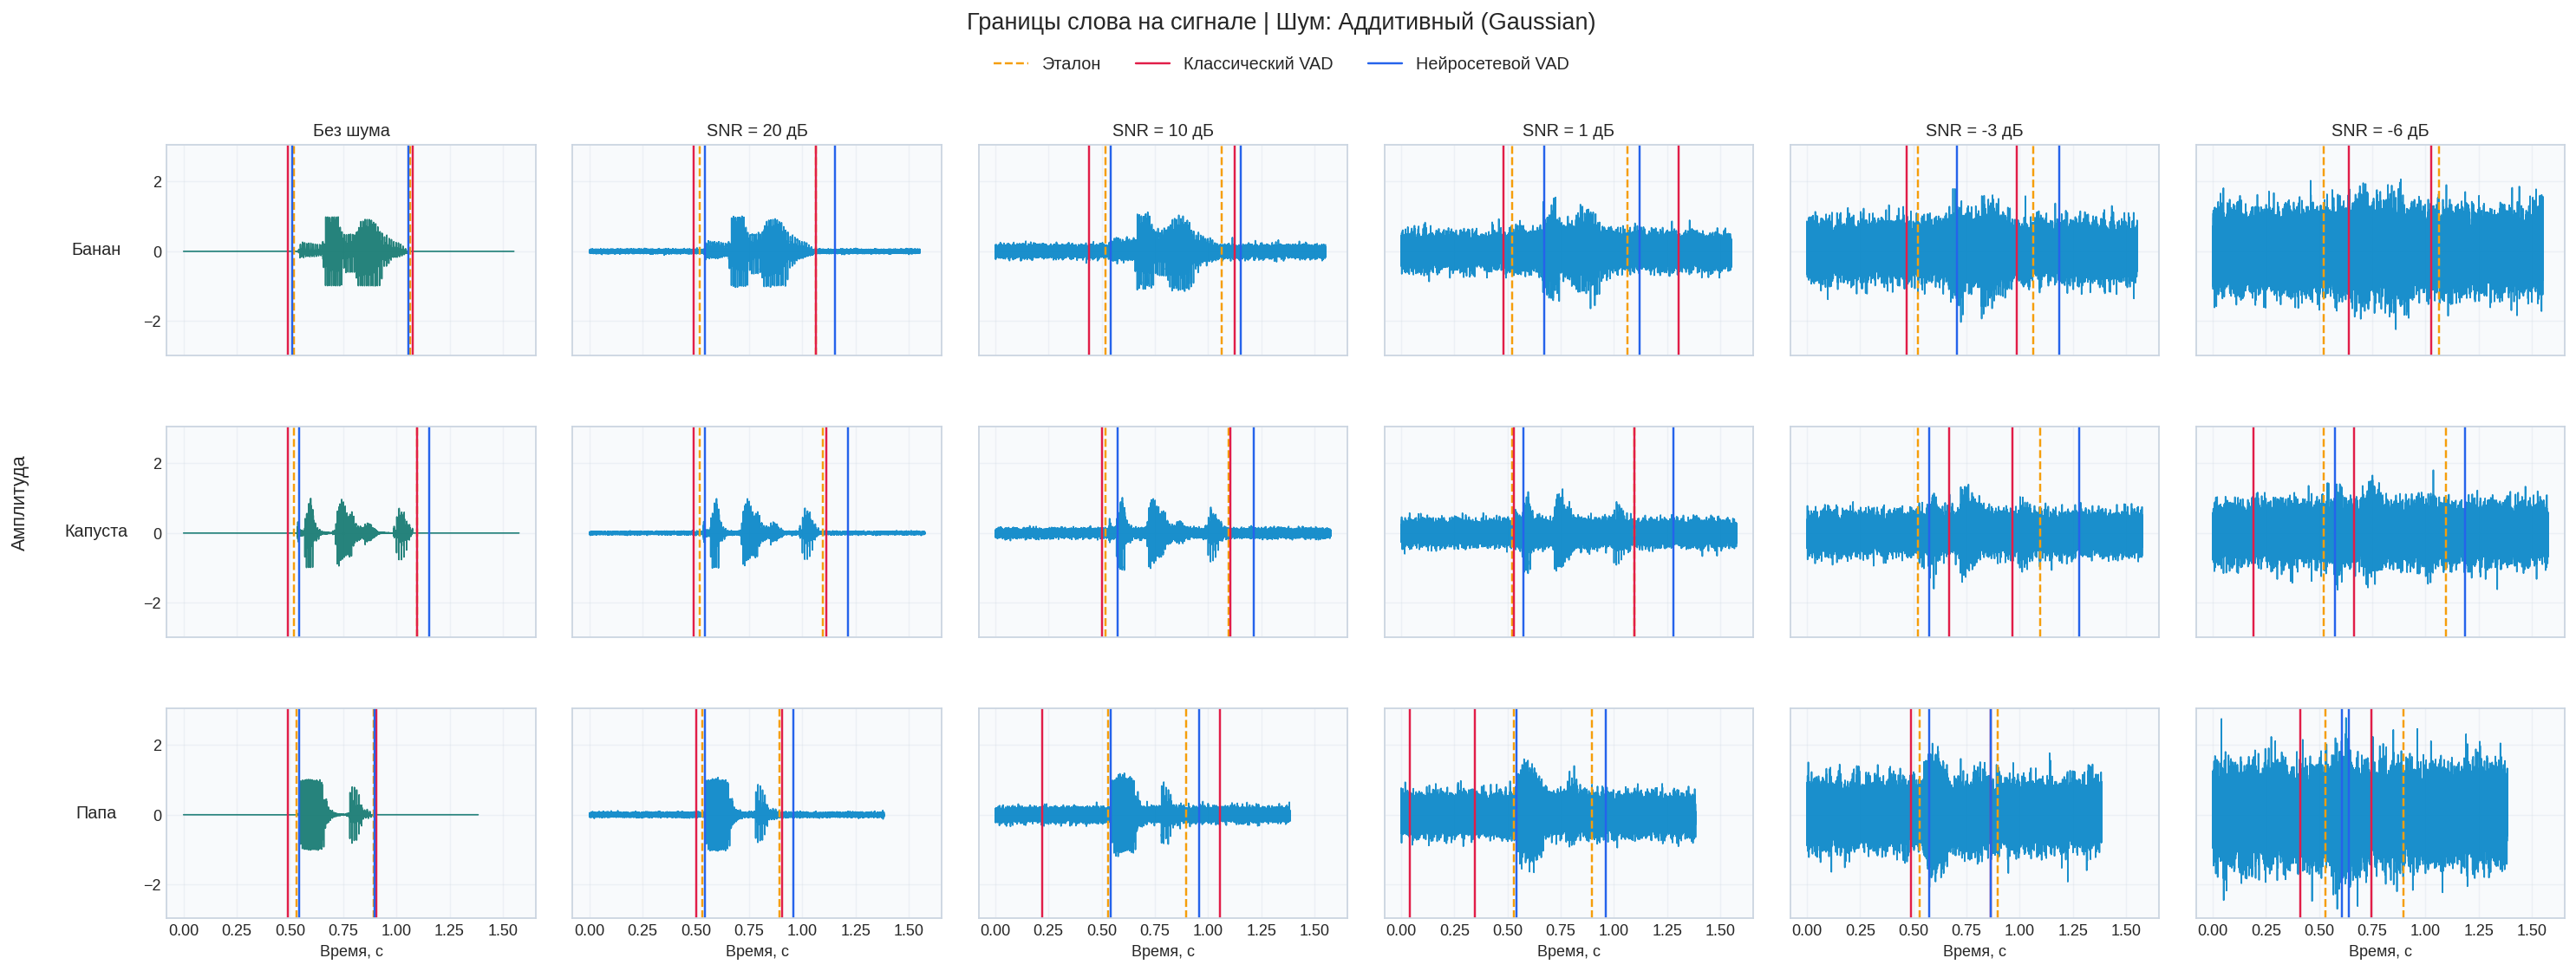

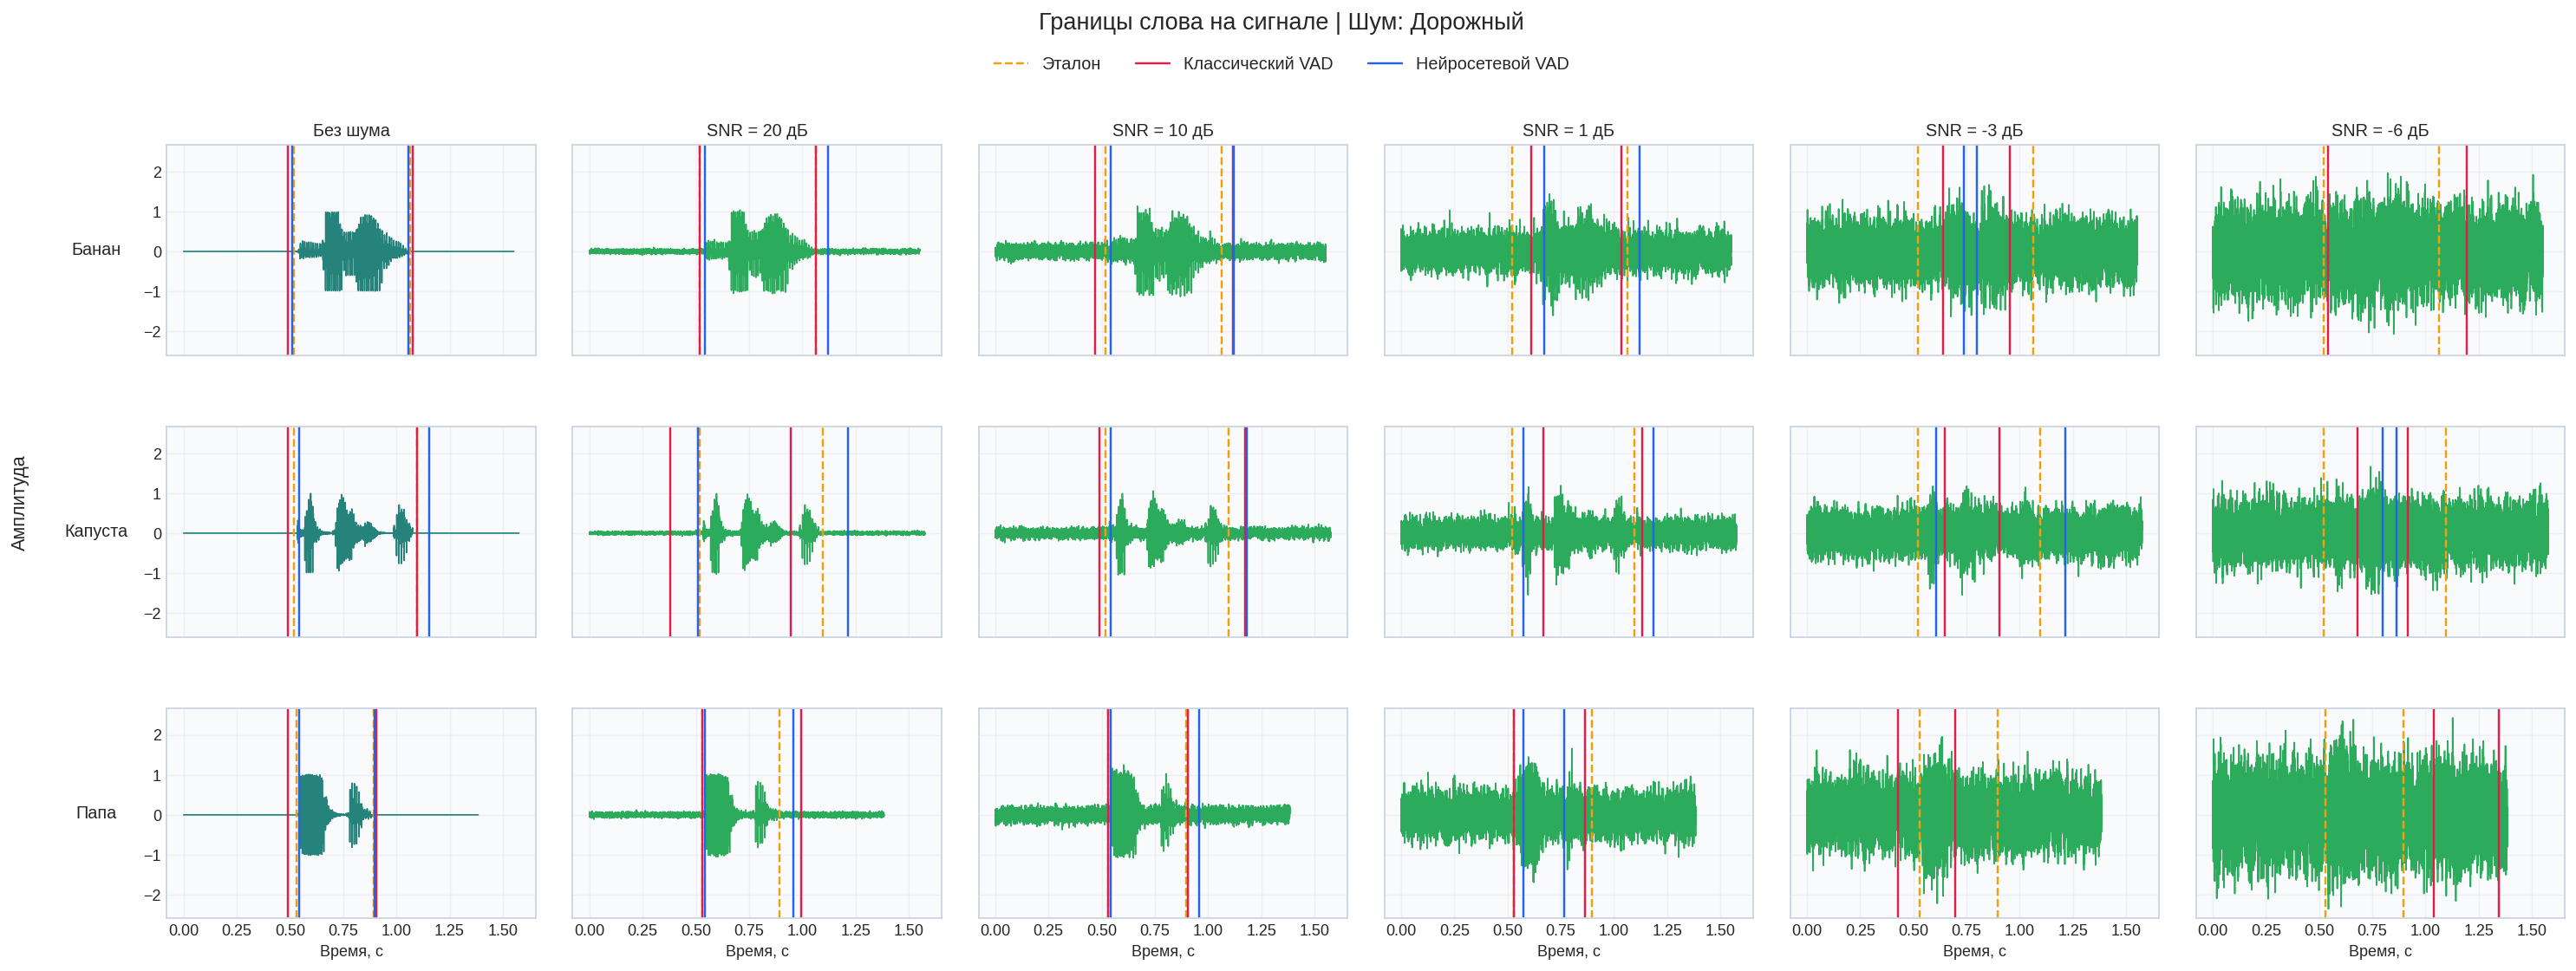

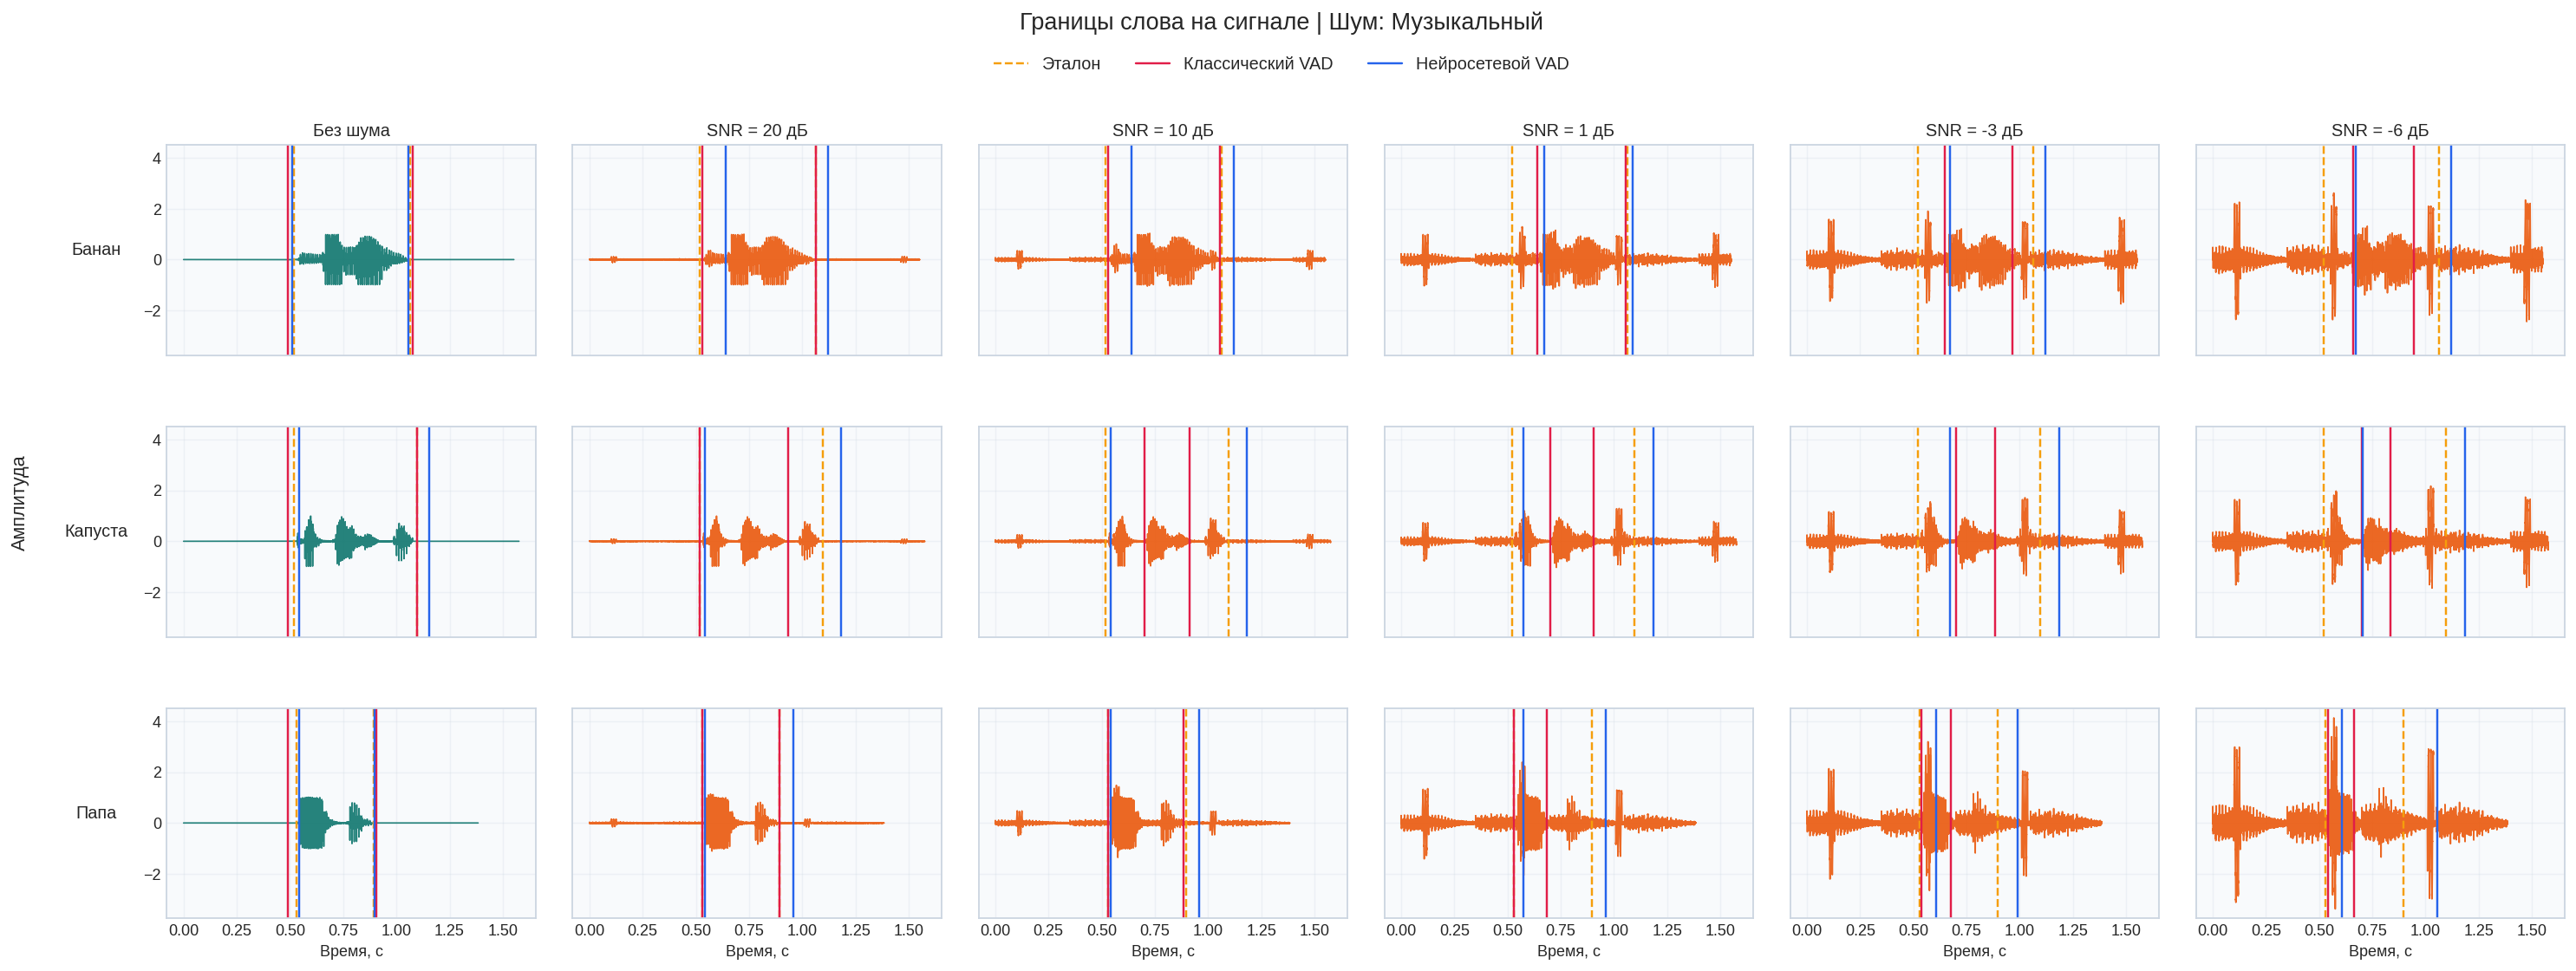

In [10]:
def neural_vad_interval(x: np.ndarray, sr: int, model: SileroOnnxVad, thr: float):
    probs, sr_vad, chunk = model.predict_prob(x, sr)
    mask = probs >= thr
    mask = smooth_mask(mask, close_k=2, open_k=1, min_len=1)

    interval = mask_to_main_interval(mask, hop_len=chunk, frame_len=chunk, sr=sr_vad)
    frame_t = (np.arange(len(probs)) * chunk + chunk / 2) / sr_vad
    return interval, mask, frame_t, probs


def interval_metrics(pred_interval: tuple[float, float], ref_interval: tuple[float, float]) -> dict:
    ps, pe = pred_interval
    rs, re = ref_interval
    ref_dur = max(1e-12, float(re - rs))

    if not (np.isfinite(ps) and np.isfinite(pe)):
        return {
            'abs_err_start': ref_dur,
            'abs_err_end': ref_dur,
            'mae_border': ref_dur,
            'dur_abs_err': ref_dur,
            'center_abs_err': ref_dur / 2,
            'iou': 0.0,
            'detected': 0.0,
        }

    ps, pe = float(ps), float(pe)
    if pe < ps:
        ps, pe = pe, ps

    inter = max(0.0, min(pe, re) - max(ps, rs))
    union = max(pe, re) - min(ps, rs)
    iou = inter / (union + 1e-12)

    pred_dur = max(0.0, pe - ps)
    ref_ctr = 0.5 * (rs + re)
    pred_ctr = 0.5 * (ps + pe)

    return {
        'abs_err_start': abs(ps - rs),
        'abs_err_end': abs(pe - re),
        'mae_border': (abs(ps - rs) + abs(pe - re)) / 2,
        'dur_abs_err': abs(pred_dur - ref_dur),
        'center_abs_err': abs(pred_ctr - ref_ctr),
        'iou': iou,
        'detected': 1.0,
    }


def frame_prf(pred_mask: np.ndarray, frame_t: np.ndarray, ref_interval: tuple[float, float]) -> tuple[float, float, float]:
    pred = np.asarray(pred_mask).astype(bool)
    ref = interval_to_frame_labels(frame_t, ref_interval).astype(bool)

    tp = np.sum(pred & ref)
    fp = np.sum(pred & (~ref))
    fn = np.sum((~pred) & ref)

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = (2 * precision * recall) / (precision + recall + 1e-12)
    return float(precision), float(recall), float(f1)


experiments = []
wave_cache = {}

for word, d in records.items():
    clean = d['clean_pad']
    sr = d['sr']
    speech_slice = d['speech_slice']
    ref_interval = d['ref_interval']
    ref_s, ref_e = ref_interval

    for nt in NOISE_TYPES:
        for snr in SNR_LEVELS:
            noise = generate_noise(nt, len(clean), sr, RNG)
            noisy = mix_with_target_snr(clean, noise, snr, speech_slice)

            cl_interval, cl_mask, cl_t = classical_vad_interval(noisy, sr, pad_sec=PAD_SEC)
            nn_interval, nn_mask, nn_t, nn_prob = neural_vad_interval(noisy, sr, silero_vad_model, silero_thr)

            cl_stats = interval_metrics(cl_interval, ref_interval)
            nn_stats = interval_metrics(nn_interval, ref_interval)

            cl_prec, cl_rec, cl_f1 = frame_prf(cl_mask, cl_t, ref_interval)
            nn_prec, nn_rec, nn_f1 = frame_prf(nn_mask, nn_t, ref_interval)

            experiments.append({
                'word': word,
                'noise': nt,
                'snr_db': snr,
                'ref_start': ref_s,
                'ref_end': ref_e,
                'classic_start': cl_interval[0],
                'classic_end': cl_interval[1],
                'nn_start': nn_interval[0],
                'nn_end': nn_interval[1],
                'classic_abs_err_start': cl_stats['abs_err_start'],
                'classic_abs_err_end': cl_stats['abs_err_end'],
                'classic_mae_border': cl_stats['mae_border'],
                'classic_dur_abs_err': cl_stats['dur_abs_err'],
                'classic_center_abs_err': cl_stats['center_abs_err'],
                'classic_iou': cl_stats['iou'],
                'classic_detected': cl_stats['detected'],
                'classic_frame_precision': cl_prec,
                'classic_frame_recall': cl_rec,
                'classic_frame_f1': cl_f1,
                'nn_abs_err_start': nn_stats['abs_err_start'],
                'nn_abs_err_end': nn_stats['abs_err_end'],
                'nn_mae_border': nn_stats['mae_border'],
                'nn_dur_abs_err': nn_stats['dur_abs_err'],
                'nn_center_abs_err': nn_stats['center_abs_err'],
                'nn_iou': nn_stats['iou'],
                'nn_detected': nn_stats['detected'],
                'nn_frame_precision': nn_prec,
                'nn_frame_recall': nn_rec,
                'nn_frame_f1': nn_f1,
            })

            wave_cache[(word, nt, snr)] = {
                'signal': noisy,
                'sr': sr,
                'ref': (ref_s, ref_e),
                'classic': cl_interval,
                'nn': nn_interval,
            }

results = pd.DataFrame(experiments)

results_overview = results.head(10)
results_overview


def add_interval_lines(ax, interval, color, label, style='-'):
    s, e = interval
    ax.axvline(s, color=color, lw=1.35, ls=style, label=label)
    ax.axvline(e, color=color, lw=1.35, ls=style)


# Готовим предсказания методов на чистых сигналах (без шума)
clean_cache = {}
clean_metrics_rows = []
for word, d in records.items():
    x_clean = d['clean_pad']
    sr_clean = d['sr']
    ref_interval = d['ref_interval']

    cl_interval, cl_mask, cl_t = classical_vad_interval(x_clean, sr_clean, pad_sec=PAD_SEC)
    nn_interval, nn_mask, nn_t, _ = neural_vad_interval(x_clean, sr_clean, silero_vad_model, silero_thr)

    cl_stats = interval_metrics(cl_interval, ref_interval)
    nn_stats = interval_metrics(nn_interval, ref_interval)

    cl_prec, cl_rec, cl_f1 = frame_prf(cl_mask, cl_t, ref_interval)
    nn_prec, nn_rec, nn_f1 = frame_prf(nn_mask, nn_t, ref_interval)

    clean_metrics_rows.append({
        'word': word,
        'classic_mae_border': cl_stats['mae_border'],
        'nn_mae_border': nn_stats['mae_border'],
        'classic_iou': cl_stats['iou'],
        'nn_iou': nn_stats['iou'],
        'classic_frame_f1': cl_f1,
        'nn_frame_f1': nn_f1,
    })

    clean_cache[word] = {
        'signal': x_clean,
        'sr': sr_clean,
        'ref': ref_interval,
        'classic': cl_interval,
        'nn': nn_interval,
    }

clean_metrics = pd.DataFrame(clean_metrics_rows)


words = list(records.keys())
snr_columns = ['clean'] + SNR_LEVELS

for nt in NOISE_TYPES:
    wave_color = '#0284c7' if nt == 'gaussian' else ('#16a34a' if nt == 'road' else '#ea580c')
    noise_title = 'Аддитивный (Gaussian)' if nt == 'gaussian' else ('Дорожный' if nt == 'road' else 'Музыкальный')

    fig, axes = plt.subplots(len(words), len(snr_columns), figsize=(23, 8.8), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for r, word in enumerate(words):
        for c, snr_tag in enumerate(snr_columns):
            ax = axes[r, c]

            if snr_tag == 'clean':
                data = clean_cache[word]
                line_color = '#0f766e'
            else:
                data = wave_cache[(word, nt, snr_tag)]
                line_color = wave_color

            x = data['signal']
            sr = data['sr']
            t = np.arange(len(x)) / sr

            ax.plot(t, x, color=line_color, lw=0.95, alpha=0.9)
            add_interval_lines(ax, data['ref'], '#f59e0b', 'Эталон', style='--')
            add_interval_lines(ax, data['classic'], '#e11d48', 'Классический VAD')
            add_interval_lines(ax, data['nn'], '#2563eb', 'Нейросетевой VAD')

            if r == 0:
                title = 'Без шума' if snr_tag == 'clean' else f'SNR = {snr_tag} дБ'
                ax.set_title(title, fontsize=11, pad=6)
            if c == 0:
                ax.set_ylabel(word, fontsize=11, rotation=0, labelpad=30, va='center')
            if r == len(words) - 1:
                ax.set_xlabel('Время, с', fontsize=10)

            ax.tick_params(axis='both', labelsize=10)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h

    fig.legend(
        list(unique.values()),
        list(unique.keys()),
        loc='upper center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.965),
        fontsize=11,
    )

    fig.suptitle(f'Границы слова на сигнале | Шум: {noise_title}', y=0.995, fontsize=15)
    fig.supylabel('Амплитуда', x=0.01, fontsize=12)

    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.07, right=0.995, hspace=0.34, wspace=0.10)
    plt.show()


## Новые метрики и выводы


In [11]:
# Сводные таблицы качества детекции границ и интервала
metric_cols = [
    'classic_mae_border', 'nn_mae_border',
    'classic_iou', 'nn_iou',
    'classic_frame_precision', 'nn_frame_precision',
    'classic_frame_recall', 'nn_frame_recall',
    'classic_frame_f1', 'nn_frame_f1',
    'classic_dur_abs_err', 'nn_dur_abs_err',
    'classic_center_abs_err', 'nn_center_abs_err',
    'classic_detected', 'nn_detected',
]

summary = (
    results
    .groupby(['noise', 'snr_db'], as_index=False)[metric_cols]
    .mean()
    .sort_values(['noise', 'snr_db'], ascending=[True, False])
)

method_long = pd.concat([
    results.rename(columns={
        'classic_mae_border': 'mae_border',
        'classic_iou': 'iou',
        'classic_frame_precision': 'frame_precision',
        'classic_frame_recall': 'frame_recall',
        'classic_frame_f1': 'frame_f1',
        'classic_dur_abs_err': 'dur_abs_err',
        'classic_center_abs_err': 'center_abs_err',
        'classic_detected': 'detected',
    }).assign(method='classic')[[
        'method', 'word', 'noise', 'snr_db',
        'mae_border', 'iou', 'frame_precision', 'frame_recall', 'frame_f1',
        'dur_abs_err', 'center_abs_err', 'detected',
    ]],
    results.rename(columns={
        'nn_mae_border': 'mae_border',
        'nn_iou': 'iou',
        'nn_frame_precision': 'frame_precision',
        'nn_frame_recall': 'frame_recall',
        'nn_frame_f1': 'frame_f1',
        'nn_dur_abs_err': 'dur_abs_err',
        'nn_center_abs_err': 'center_abs_err',
        'nn_detected': 'detected',
    }).assign(method='neural')[[
        'method', 'word', 'noise', 'snr_db',
        'mae_border', 'iou', 'frame_precision', 'frame_recall', 'frame_f1',
        'dur_abs_err', 'center_abs_err', 'detected',
    ]],
], ignore_index=True)

overall = (
    method_long
    .groupby('method', as_index=False)[[
        'mae_border', 'iou', 'frame_precision', 'frame_recall', 'frame_f1',
        'dur_abs_err', 'center_abs_err', 'detected',
    ]]
    .mean()
)

core_cols = [
    'noise', 'snr_db',
    'classic_mae_border', 'nn_mae_border',
    'classic_iou', 'nn_iou',
    'classic_frame_f1', 'nn_frame_f1',
]
ext_cols = [
    'noise', 'snr_db',
    'classic_frame_precision', 'nn_frame_precision',
    'classic_frame_recall', 'nn_frame_recall',
    'classic_dur_abs_err', 'nn_dur_abs_err',
    'classic_center_abs_err', 'nn_center_abs_err',
    'classic_detected', 'nn_detected',
]

core_summary = summary[core_cols].copy().round(3)
extended_summary = summary[ext_cols].copy().round(3)
clean_summary = clean_metrics.copy().round(3)
overall_summary = overall.copy().round(3)

wins_mae = int((summary['classic_mae_border'] <= summary['nn_mae_border']).sum())
wins_iou = int((summary['classic_iou'] >= summary['nn_iou']).sum())
wins_f1 = int((summary['classic_frame_f1'] >= summary['nn_frame_f1']).sum())
total_cases = int(len(summary))

wins_summary = pd.DataFrame([
    {
        'metric': 'mae_border',
        'classic_wins': wins_mae,
        'neural_wins': total_cases - wins_mae,
        'total_cases': total_cases,
    },
    {
        'metric': 'iou',
        'classic_wins': wins_iou,
        'neural_wins': total_cases - wins_iou,
        'total_cases': total_cases,
    },
    {
        'metric': 'frame_f1',
        'classic_wins': wins_f1,
        'neural_wins': total_cases - wins_f1,
        'total_cases': total_cases,
    },
])

best_summary = pd.DataFrame([
    {
        'criterion': 'min_mae_border',
        'best_method': overall.loc[overall['mae_border'].idxmin(), 'method'],
    },
    {
        'criterion': 'max_iou',
        'best_method': overall.loc[overall['iou'].idxmax(), 'method'],
    },
    {
        'criterion': 'max_frame_f1',
        'best_method': overall.loc[overall['frame_f1'].idxmax(), 'method'],
    },
])


def style_table(df: pd.DataFrame, caption: str):
    return (
        df.style
        .format(precision=3)
        .set_caption(caption)
        .set_table_styles([
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '1.05em'), ('font-weight', 'bold')]},
        ])
    )


display(style_table(core_summary, 'Ключевые метрики по каждому noise × SNR'))
display(style_table(extended_summary, 'Дополнительные метрики (precision/recall, ошибки длительности/центра, detected)'))
display(style_table(clean_summary, 'Метрики на чистом сигнале (без шума)'))
display(style_table(overall_summary, 'Итог по всем экспериментам: среднее по методам'))
display(style_table(wins_summary, 'Количество побед по условиям (classic vs neural)'))
display(style_table(best_summary, 'Лучший метод по каждому критерию'))


,noise,snr_db,classic_mae_border,nn_mae_border,classic_iou,nn_iou,classic_frame_f1,nn_frame_f1
4,gaussian,20,0.020,0.056,0.923,0.811,0.734,0.892
3,gaussian,10,0.107,0.061,0.728,0.795,0.647,0.883
2,gaussian,1,0.222,0.088,0.548,0.718,0.636,0.830
1,gaussian,-3,0.080,0.103,0.707,0.672,0.587,0.796
0,gaussian,-6,0.198,0.261,0.437,0.290,0.540,0.344
9,music,20,0.028,0.061,0.901,0.785,0.872,0.875
8,music,10,0.065,0.061,0.770,0.785,0.829,0.875
7,music,1,0.118,0.072,0.514,0.738,0.727,0.845
6,music,-3,0.142,0.104,0.423,0.638,0.685,0.767
5,music,-6,0.157,0.120,0.367,0.596,0.627,0.725


,noise,snr_db,classic_frame_precision,nn_frame_precision,classic_frame_recall,nn_frame_recall,classic_dur_abs_err,nn_dur_abs_err,classic_center_abs_err,nn_center_abs_err,classic_detected,nn_detected
4,gaussian,20,0.585,0.833,0.994,0.962,0.040,0.070,0.010,0.056,1.000,1.000
3,gaussian,10,0.483,0.829,1.000,0.943,0.213,0.060,0.030,0.061,1.000,1.000
2,gaussian,1,0.481,0.810,0.947,0.865,0.117,0.092,0.208,0.088,1.000,1.000
1,gaussian,-3,0.450,0.820,0.858,0.785,0.107,0.090,0.037,0.093,1.000,1.000
0,gaussian,-6,0.424,0.614,0.745,0.327,0.097,0.304,0.185,0.144,1.000,0.667
9,music,20,0.827,0.854,0.924,0.903,0.057,0.060,0.028,0.061,1.000,1.000
8,music,10,0.814,0.854,0.851,0.903,0.130,0.060,0.002,0.061,1.000,1.000
7,music,1,0.777,0.866,0.687,0.835,0.237,0.060,0.055,0.072,1.000,1.000
6,music,-3,0.762,0.791,0.624,0.749,0.283,0.060,0.045,0.104,1.000,1.000
5,music,-6,0.738,0.731,0.551,0.730,0.313,0.092,0.053,0.120,1.000,1.000


,word,classic_mae_border,nn_mae_border,classic_iou,nn_iou,classic_frame_f1,nn_frame_f1
0,Банан,0.020,0.008,0.932,0.969,0.982,1.000
1,Капуста,0.015,0.040,0.950,0.872,0.974,0.919
2,Папа,0.025,0.008,0.880,0.959,0.961,1.000


,method,mae_border,iou,frame_precision,frame_recall,frame_f1,dur_abs_err,center_abs_err,detected
0,classic,0.112,0.643,0.587,0.835,0.668,0.145,0.068,1.000
1,neural,0.120,0.631,0.770,0.735,0.725,0.129,0.086,0.911


,metric,classic_wins,neural_wins,total_cases
0,mae_border,8,7,15
1,iou,8,7,15
2,frame_f1,3,12,15


,criterion,best_method
0,min_mae_border,classic
1,max_iou,classic
2,max_frame_f1,neural


## Выводы

1. Когда важны точные границы слова, классический VAD в среднем работает чуть стабильнее.
2. Когда важна покадровая разметка речи, нейросетевой VAD показывает себя лучше.
3. Проблемное место нейросети — сильный шум и низкий `SNR` (особенно дорожный шум): в части случаев слово пропускается.
4. Классический метод чаще находит само слово, но может менее точно выделять его форму внутри интервала.
5. Рабочий практичный вариант: нейросеть как основной метод, классический — как проверка в самых шумных условиях.
6. Если приоритет проекта — границы слова, нейросеть стоит дополнительно дообучить под шумные сценарии.
